# Wind & Solar Energy Forecasting (France) — Full Pipeline

**Goal:** forecast the hourly production of wind + solar energy in France (`Production`, MW) 1h, 6h and 24h ahead, and find out which approach works best.

| Step | What we do | Who |
|---|---|---|
| 1 | Setup | all |
| 2 | Data loading, cleaning, weather merge, chronological split | Person A |
| 3 | Load the processed data (strict hourly grid) | all |
| 4 | Explore: daily cycle, seasons, trend | all |
| 5 | Stationarity tests (ADF & KPSS) | time-series diagnostics |
| 6 | ACF / PACF | time-series diagnostics |
| 7 | Train / test split | Person A |
| 8 | Evaluation tools: MAE, RMSE, MASE | Person C |
| 9 | Baselines: naive and seasonal naive | Person C |
| 10 | Supervised models: Linear, Ridge, Random Forest, LightGBM (+ cluster-aware) | Person C |
| 11 | Classical ARIMA models | time-series diagnostics |
| 12 | Final comparison | Person C |
| 13 | The cluster-label leakage | Person B / C |
| 14 | Error by season and by cluster | Person C |
| 15 | Residual diagnostics | time-series diagnostics |
| 16 | Forecast vs actual | all |
| 17 | Conclusions and limitations | all |

> **Note on the code:** every code cell that defines a function or constant is copied **as-is** from the project files in `src/`. The only differences from the `.py` files are (1) the `import` lines are gathered in the Setup cell, (2) imports *between* our own files are removed because the functions are already defined in earlier cells, and (3) the `if __name__ == "__main__"` blocks are replaced by explicit calls. Cells marked **(extra)** are only for exploration and display.

## 1. Setup
Imports are the union of the imports used by all our files. The two lines that define `ROOT` and `__file__` let the code that uses `os.path.dirname(__file__)` find the repository folders even inside a notebook (a notebook has no `__file__`).

**Flags** (change them as needed):
- `RUN_MODELS`: `True` re-trains all supervised models (about 3-10 min). `False` just reads the saved tables in `results/`.
- `RUN_ARIMA`: `True` re-fits the ARIMA models and regenerates `arima_results.csv` and the residual plots (several minutes). **Run it once with `True`** so that the corrected ARIMA results replace the old ones.
- `QUICK_RUN`: `True` uses tiny hyper-parameter grids, only to check that everything runs.

In [1]:
import pandas as pd
import os
import numpy as np
import argparse
import time
import warnings
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from pathlib import Path
from IPython.display import Image, display

# --- locate the repository root (folder that contains `src` and `data`)
ROOT = Path.cwd()
while not ((ROOT / "src").exists() and (ROOT / "data").exists()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
__file__ = str(ROOT / "src" / "notebook.py")   # lets `os.path.dirname(__file__)` work inside a notebook

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
%matplotlib inline

# --- flags
RUN_MODELS = False
RUN_ARIMA  = True
QUICK_RUN  = False
print("Repository root:", ROOT)

Repository root: c:\Users\Administrator\Desktop\Wind-Solar-Forecasting


## 2. Data loading and preprocessing (Person A)
**What:** the raw file has the date and the start hour in separate columns, plus several redundant columns. These functions build a proper hourly time index, clean the data, add the weather, and split it in time.

**Why each step exists:**
- `load_raw`: builds `datetime = Date + Start_Hour` and sorts by it. Time-series models need a correct, ordered time index.
- `clean`: removes duplicate timestamps and negative production values (physically impossible).
- `merge_weather`: adds NASA POWER weather (wind speed, temperature, irradiation, cloud cover) averaged per hour so it aligns with production. It is a *left* join so no production row is lost, and small gaps (up to 3 hours) are forward-filled.
- `chronological_split`: 80% oldest hours for training, 20% newest for testing, **no shuffling**. Shuffling would let the model see the future (leakage).
- `save_processed`: writes the results to `data/processed/`.

> The raw dataset stays on the local machine (it is not pushed to GitHub), so we only **define** these functions here. Their outputs are the files already stored in `data/processed/`.

In [2]:
RAW_PATH_LOCAL   = os.path.join(os.path.dirname(__file__), "..", "data", "raw", "Energy Production Dataset.csv")
RAW_PATH_DESKTOP = r"C:\Users\mhesh\Desktop\Energy Production Dataset.csv"
RAW_PATH         = RAW_PATH_LOCAL if os.path.exists(RAW_PATH_LOCAL) else RAW_PATH_DESKTOP
WEATHER_PATH     = os.path.join(os.path.dirname(__file__), "..", "data", "external", "france_weather.csv")
PROCESSED_DIR    = os.path.join(os.path.dirname(__file__), "..", "data", "processed")

In [3]:
def load_raw() -> pd.DataFrame:
    """Read the raw CSV and return a tidy DataFrame with a proper datetime index."""
    df = pd.read_csv(RAW_PATH)

    # Build a proper datetime column from Date + Start_Hour
    df["datetime"] = pd.to_datetime(df["Date"], dayfirst=False) + pd.to_timedelta(df["Start_Hour"], unit="h")
    df = df.sort_values("datetime").reset_index(drop=True)
    df = df.set_index("datetime")

    # Drop columns that are redundant once we have the datetime index
    df = df.drop(columns=["Date", "End_Hour", "Day_of_Year", "Day_Name", "Month_Name", "Season"])

    return df

In [4]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicates and filter invalid rows."""
    # Drop duplicate timestamps (keep first)
    df = df[~df.index.duplicated(keep="first")]

    # Production must be non-negative
    df = df[df["Production"] >= 0]

    return df

In [5]:
def merge_weather(df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge historical France weather data (NASA POWER) into the production DataFrame.
    Weather columns added:
      - wind_speed_10m : wind speed at 10 m (m/s)
      - temp_2m        : air temperature at 2 m (degC)
      - irradiation    : surface solar irradiation (kW-hr/m^2/day)
      - cloud_cover    : cloud amount (%)

    If the weather file does not exist yet, returns df unchanged with a warning.
    """
    weather_path = os.path.abspath(WEATHER_PATH)
    if not os.path.exists(weather_path):
        print("[WARNING] Weather file not found. Skipping weather merge.")
        print(f"          Expected at: {weather_path}")
        return df

    weather = pd.read_csv(weather_path, index_col="datetime", parse_dates=True)

    # NASA POWER returns minute-level timestamps (YYYYMMDDHHNN where NN = minutes).
    # We need to aggregate to hourly means so timestamps align with production data.
    weather.index = weather.index.tz_localize(None)
    weather = weather.resample("h").mean()          # average any sub-hourly readings

    # Left-join on datetime index so production rows are never dropped
    merged = df.join(weather, how="left")

    # Forward-fill small gaps (e.g. missing hours at boundaries)
    weather_cols = ["wind_speed_10m", "temp_2m", "irradiation", "cloud_cover"]
    merged[weather_cols] = merged[weather_cols].ffill(limit=3)

    n_nan = merged[weather_cols].isnull().sum().sum()
    print(f"Weather merged. Total NaN in weather cols: {n_nan}")
    return merged

In [6]:
def chronological_split(df: pd.DataFrame, test_ratio: float = 0.2):
    """Simple time-based train / test split (no shuffling)."""
    split_idx = int(len(df) * (1 - test_ratio))
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
    return train, test


def save_processed(df: pd.DataFrame, filename: str):
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    path = os.path.join(PROCESSED_DIR, filename)
    df.to_csv(path)
    print(f"Saved -> {path}")

## 3. Load the processed data
`load_splits` reads the train/test files that already contain the features (Person A) and the daily cluster label (Person B).

`regular_hourly_series` puts `Production` on a **strict hourly grid**: if an hour is missing it becomes `NaN` instead of disappearing. This matters because later we use `shift(24)` to mean "24 hours ago". On a series with missing rows, `shift(24)` would silently mean "24 rows ago".

In [7]:
BASE_DIR      = os.path.join(os.path.dirname(__file__), "..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
TABLES_DIR    = os.path.join(BASE_DIR, "results", "tables")
TARGET   = "Production"
HORIZONS = [1, 6, 24]

In [8]:
def load_splits():
    for f in ("train_features_clustered.csv", "test_features_clustered.csv"):
        if not os.path.exists(os.path.join(PROCESSED_DIR, f)):
            raise FileNotFoundError(
                f"data/processed/{f} not found. Run `git pull` first; if it is still missing, "
                "ask Person A/B to push data/processed/ (or send you the file).")
    train = pd.read_csv(os.path.join(PROCESSED_DIR, "train_features_clustered.csv"),
                        index_col="datetime", parse_dates=True)
    test = pd.read_csv(os.path.join(PROCESSED_DIR, "test_features_clustered.csv"),
                       index_col="datetime", parse_dates=True)
    return train, test


def regular_hourly_series(train: pd.DataFrame, test: pd.DataFrame) -> pd.Series:
    """Train+test Production on a strict hourly grid (missing hours become NaN),
    so shift(24) means exactly 24 hours."""
    full = pd.concat([train[TARGET], test[TARGET]]).sort_index()
    full = full[~full.index.duplicated(keep="first")]
    return full.asfreq("h")

In [9]:
train, test = load_splits()
full = regular_hourly_series(train, test)   # strict hourly grid, gaps = NaN

print("Train:", train.index.min(), "->", train.index.max(), f"({len(train)} rows)")
print("Test :", test.index.min(), "->", test.index.max(), f"({len(test)} rows)")
print("Missing hourly timestamps in the full grid:", int(full.isna().sum()))
display(train[["Production", "wind_speed_10m", "temp_2m", "irradiation", "cloud_cover", "cluster"]].head())

Train: 2020-01-08 00:00:00 -> 2024-09-26 04:00:00 (41352 rows)
Test : 2024-09-26 05:00:00 -> 2025-11-30 23:00:00 (10338 rows)
Missing hourly timestamps in the full grid: 6


,Production,wind_speed_10m,temp_2m,irradiation,cloud_cover,cluster
datetime,,,,,,
2020-01-08 00:00:00,5674,2.69,5.26,0.0,96.66,0
2020-01-08 01:00:00,5852,2.67,5.42,0.0,52.66,0
2020-01-08 02:00:00,6008,2.33,5.45,0.0,68.86,0
2020-01-08 03:00:00,5919,1.96,5.40,0.0,77.13,0
2020-01-08 04:00:00,5673,1.81,5.36,0.0,68.35,0


## 4. Explore the data (extra)
**Why:** before modelling we look at what the series looks like.
- **Left:** a summer week and a winter week. Production has a clear **daily cycle** (solar peaks at midday) and the level changes with the season.
- **Right:** the daily average with a 30-day moving average. The moving average smooths out the day-to-day noise and shows the **seasonal level** (higher in summer, lower in winter). A moving average reduces noise; it does not remove seasonality.

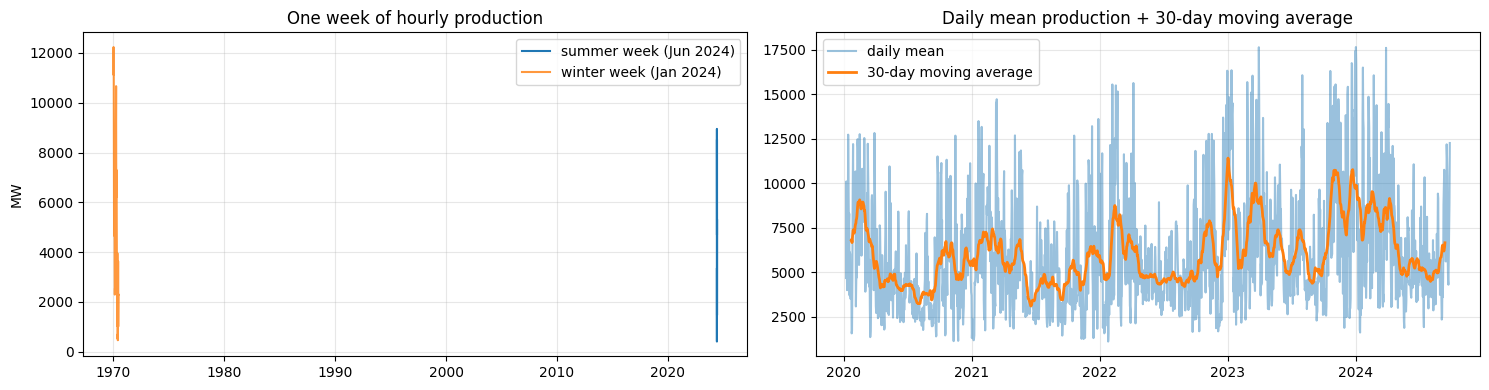

In [10]:
y_train = full.loc[:train.index.max()]
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(y_train.loc["2024-06-03":"2024-06-09"], label="summer week (Jun 2024)")
ax[0].plot(y_train.loc["2024-01-08":"2024-01-14"].values, label="winter week (Jan 2024)", alpha=.8)
ax[0].set_title("One week of hourly production"); ax[0].set_ylabel("MW"); ax[0].legend(); ax[0].grid(alpha=.3)

daily = y_train.resample("D").mean()
ax[1].plot(daily, alpha=.45, label="daily mean")
ax[1].plot(daily.rolling(30, center=True).mean(), linewidth=2, label="30-day moving average")
ax[1].set_title("Daily mean production + 30-day moving average"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Stationarity: ADF and KPSS tests
A **stationary** series has a constant mean, constant variance and a stable relationship with its own past. Classical models such as ARIMA assume it.

- **ADF**: H0 = *non-stationary* (has a unit root). If p < 0.05 we reject H0, so the series is stationary.
- **KPSS**: H0 = *stationary* (the opposite). If p < 0.05 we reject H0, so the series is **not** stationary.

**Our result:** ADF statistic = -16.34 (p = 0.0) → stationary. KPSS statistic = 2.80 (p = 0.01, the smallest value the library reports) → non-stationary. The two tests **disagree**. The reason is that our series has no explosive trend (ADF is satisfied), but its **mean moves with the seasons** (summer is much higher than winter), which KPSS detects. With 41,000 points both tests are very sensitive. That is why we try both `d = 0` and `d = 1` in the ARIMA models.

In [11]:
warnings.filterwarnings("ignore")
BASE_DIR   = os.path.join(os.path.dirname(__file__), "..")
TABLES_DIR = os.path.join(BASE_DIR, "results", "tables")
FIGS_DIR   = os.path.join(BASE_DIR, "results", "figures")
PRED_DIR   = os.path.join(BASE_DIR, "results", "predictions")

In [12]:
def apply_style():
    plt.style.use("seaborn-v0_8-darkgrid")

def savefig(path: str, **kwargs):
    plt.savefig(path, bbox_inches="tight", dpi=150, **kwargs)
    print(f"Saved -> {path}")

In [13]:
def run_stationarity_tests(series: pd.Series) -> pd.DataFrame:
    """Run ADF and KPSS tests to diagnose stationarity and trend/differencing needs."""
    s_clean = series.dropna()
    
    # ADF test (H0: non-stationary / unit root)
    adf_res = adfuller(s_clean)
    adf_stat, adf_p = adf_res[0], adf_res[1]
    adf_result = "stationary" if adf_p < 0.05 else "non-stationary"
    
    # KPSS test (H0: stationary)
    kpss_res = kpss(s_clean, nlags="auto")
    kpss_stat, kpss_p = kpss_res[0], kpss_res[1]
    kpss_result = "non-stationary" if kpss_p < 0.05 else "stationary"
    
    # Interpretation
    if adf_result == "stationary" and kpss_result == "stationary":
        summary = "Strictly Stationary"
    elif adf_result == "non-stationary" and kpss_result == "non-stationary":
        summary = "Non-Stationary (Differencing Required)"
    else:
        summary = "Possible Level Shift / Structural Trend"

    results = [
        {"Test": "ADF (Augmented Dickey-Fuller)", "Statistic": round(adf_stat, 4), "p_value": round(adf_p, 4), "Conclusion": adf_result},
        {"Test": "KPSS Test", "Statistic": round(kpss_stat, 4), "p_value": round(kpss_p, 4), "Conclusion": kpss_result},
    ]
    df_res = pd.DataFrame(results)
    
    print("\n--- 1. Stationarity Diagnostic Tests ---")
    print(df_res.to_string(index=False))
    print(f"Overall Diagnosis: {summary}\n")
    
    df_res.to_csv(os.path.join(TABLES_DIR, "stationarity_tests.csv"), index=False)
    return df_res

In [14]:
os.makedirs(TABLES_DIR, exist_ok=True); os.makedirs(FIGS_DIR, exist_ok=True)   # (extra) make sure the folders exist
stationarity = run_stationarity_tests(full.loc[:train.index.max()])


--- 1. Stationarity Diagnostic Tests ---
                         Test  Statistic  p_value     Conclusion
ADF (Augmented Dickey-Fuller)   -16.3403     0.00     stationary
                    KPSS Test     2.7986     0.01 non-stationary
Overall Diagnosis: Possible Level Shift / Structural Trend



## 6. ACF and PACF
- **ACF** = correlation of the series with itself at lag 1, 2, 3, ... hours.
- **PACF** = the *direct* correlation at each lag after removing the effect of the shorter lags.
- Rule of thumb: the **PACF cutting off** suggests the AR order `p`; the **ACF cutting off** suggests the MA order `q`.

**What we see:**
- **Raw series (top):** the ACF decays slowly and rises again around **lag 24** (about 0.6): a **daily cycle**.
- **After 1 difference (bottom):** the ACF is positive at lags 1-2, negative between lags 5-20, and has a big hump again around **lag 24 and 48**. The daily seasonality is still there after differencing.
- **Meaning:** a simple ARIMA(p,d,q) only captures short-term momentum. The 24-hour cycle would need a seasonal model (SARIMA, period 24). Our supervised models capture it directly with the features `hour` and `lag_24h`.

In [15]:
def plot_acf_pacf_analysis(series: pd.Series):
    """Plot ACF and PACF for raw series and differenced series (d=1)."""
    apply_style()
    s_clean = series.dropna()
    diff1 = s_clean.diff().dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    
    # Raw series ACF & PACF
    plot_acf(s_clean, lags=48, zero=False, ax=axes[0, 0], color="#4C9BE8")
    axes[0, 0].set_title("ACF - Raw Series (48h Lags)")
    axes[0, 0].grid(alpha=0.3)
    
    plot_pacf(s_clean, lags=48, zero=False, ax=axes[0, 1], method="ywm", color="#4C9BE8")
    axes[0, 1].set_title("PACF - Raw Series (48h Lags)")
    axes[0, 1].grid(alpha=0.3)
    
    # Differenced series ACF & PACF
    plot_acf(diff1, lags=48, zero=False, ax=axes[1, 0], color="#F5A623")
    axes[1, 0].set_title("ACF - 1st Difference d=1 (q parameter)")
    axes[1, 0].grid(alpha=0.3)
    
    plot_pacf(diff1, lags=48, zero=False, ax=axes[1, 1], method="ywm", color="#F5A623")
    axes[1, 1].set_title("PACF - 1st Difference d=1 (p parameter)")
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    savefig(os.path.join(FIGS_DIR, "04_acf_pacf_analysis.png"))
    plt.close()
    print("Saved ACF & PACF diagnostic plot -> results/figures/04_acf_pacf_analysis.png")

Saved -> c:\Users\Administrator\Desktop\Wind-Solar-Forecasting\src\..\results\figures\04_acf_pacf_analysis.png
Saved ACF & PACF diagnostic plot -> results/figures/04_acf_pacf_analysis.png


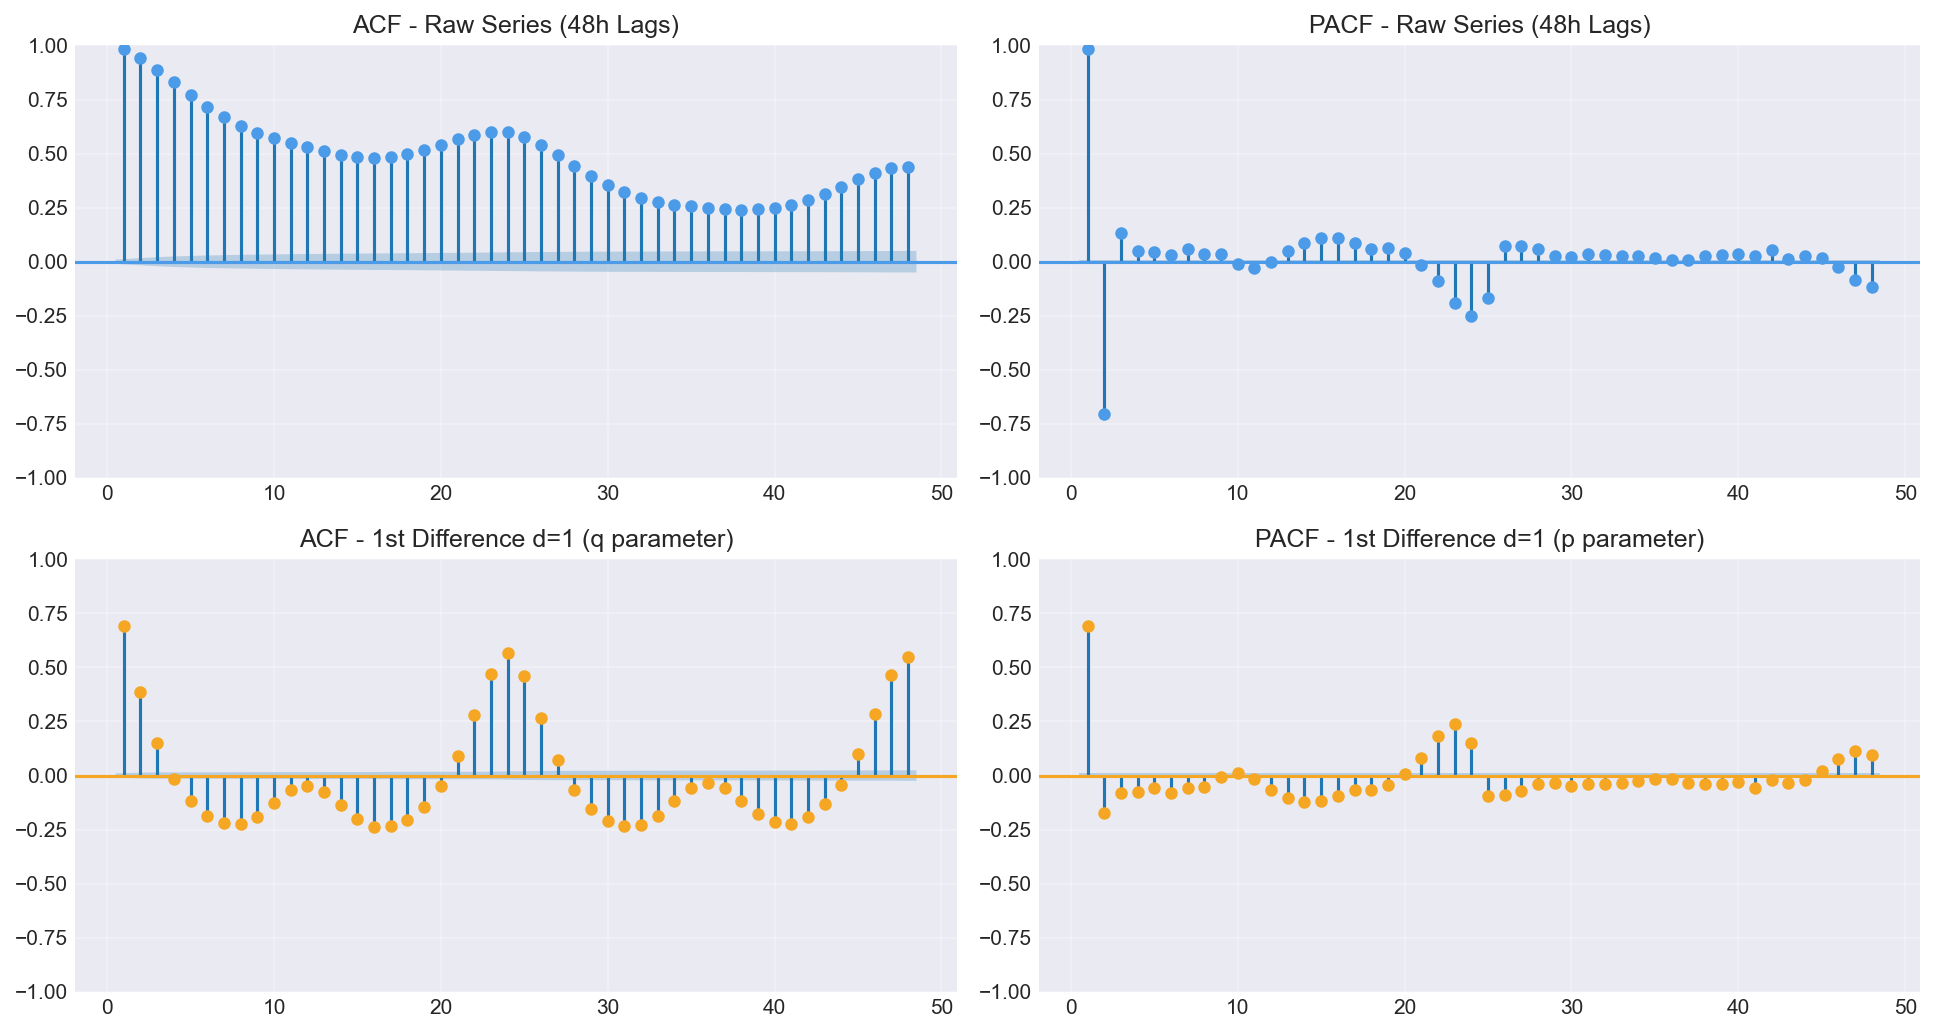

In [16]:
plot_acf_pacf_analysis(full.loc[:train.index.max()])
display(Image(os.path.join(FIGS_DIR, "04_acf_pacf_analysis.png")))   # (extra) show the saved figure

## 7. Train / test split
The split is **chronological**: the model learns from the past and is examined on the future, like in real life. All tuning is done inside the training set only; the test set is used once at the end.

In [17]:
print(f"Train: {train.index.min():%Y-%m-%d} -> {train.index.max():%Y-%m-%d}  ({len(train):,} hours)")
print(f"Test : {test.index.min():%Y-%m-%d} -> {test.index.max():%Y-%m-%d}  ({len(test):,} hours)")
print("Test share of the data: %.1f%%" % (100 * len(test) / (len(train) + len(test))))

Train: 2020-01-08 -> 2024-09-26  (41,352 hours)
Test : 2024-09-26 -> 2025-11-30  (10,338 hours)
Test share of the data: 20.0%


## 8. Evaluation tools (MAE, RMSE, MASE)
- **MAE**: the average size of the error, in MW. Easy to read.
- **RMSE**: squares the errors first, so big mistakes weigh more. If RMSE is much larger than MAE, there are a few big errors.
- **MASE**: MAE divided by the MAE of the "same hour yesterday" forecast **on the training set** (`mase_scale`). MASE < 1 means better than that simple forecast. It has no unit, so horizons and clusters can be compared.
- `season_series` assigns each hour to Winter / Spring / Summer / Autumn. `evaluate_by_group` repeats the metrics per season or per cluster.

In [18]:
SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]

In [19]:
def season_series(index: pd.DatetimeIndex) -> pd.Series:
    """Meteorological season for each timestamp (ordered categorical)."""
    s = pd.Series(index.month, index=index).map(SEASON_MAP)
    return pd.Series(pd.Categorical(s, categories=SEASON_ORDER, ordered=True), index=index)


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

In [20]:
def mase_scale(y_train, m: int = 24) -> float:
    """
    MASE denominator = MAE of the seasonal-naive forecast (lag m) on the TRAIN set.
    Same definition as Person B (m=24), so all MASE numbers in the project are comparable.
    Pass a regular hourly series (gaps as NaN) so lag m really means m hours.
    """
    y = np.asarray(y_train, dtype=float)
    d = np.abs(y[m:] - y[:-m])
    d = d[~np.isnan(d)]
    return float(d.mean())


def evaluate(y_true, y_pred, scale: float) -> dict:
    """MAE / RMSE / MASE on the rows where both y_true and y_pred exist."""
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(yt) | np.isnan(yp))
    yt, yp = yt[mask], yp[mask]
    m = mae(yt, yp)
    return {"N": int(mask.sum()), "MAE": m, "RMSE": rmse(yt, yp), "MASE": m / scale}


def evaluate_by_group(y_true: pd.Series, y_pred: pd.Series, groups: pd.Series,
                      scale: float, group_name: str = "group") -> pd.DataFrame:
    """Same metrics, computed separately for each value of `groups` (season, cluster...)."""
    df = pd.DataFrame({"y": y_true, "p": y_pred, "g": groups})
    rows = []
    for g, sub in df.groupby("g", sort=True, observed=True):
        r = evaluate(sub["y"], sub["p"], scale)
        r[group_name] = g
        rows.append(r)
    return pd.DataFrame(rows)[[group_name, "N", "MAE", "RMSE", "MASE"]]

In [21]:
scale = mase_scale(full.loc[:train.index.max()], m=24)
print(f"MASE scale = {scale:.2f} MW  (train MAE of 'same hour yesterday')")

# (extra) tiny worked example of the three metrics
y_true_demo = [5000, 6000, 7000]; y_pred_demo = [5400, 5700, 7100]
print("MAE:", round(mae(y_true_demo, y_pred_demo), 1), "| RMSE:", round(rmse(y_true_demo, y_pred_demo), 1))

MASE scale = 2498.50 MW  (train MAE of 'same hour yesterday')
MAE: 266.7 | RMSE: 294.4


## 9. Baselines
A **baseline** is a very simple forecast that any real model must beat; otherwise the model is not worth its complexity. For a target hour T forecast at origin T-h:
- **Naive**: the last value we know, `y[T-h]`.
- **Seasonal naive (24h)**: the same hour yesterday, `y[T-24]`.
- **Seasonal naive (168h)**: the same hour last week, `y[T-168]`.

At h = 24 the naive and the daily seasonal naive are identical (the last known value *is* yesterday's value), so their rows coincide.

In [22]:
BASELINES = {   # key -> display name
    "naive":      "Naive (last known value)",
    "snaive_24":  "Seasonal naive (same hour yesterday)",
    "snaive_168": "Seasonal naive (same hour last week)",
}

In [23]:
def baseline_prediction(full: pd.Series, key: str, horizon: int) -> pd.Series:
    if key == "naive":
        return full.shift(horizon)
    if key == "snaive_24":
        assert horizon <= 24, "daily seasonal naive needs horizon <= 24h"
        return full.shift(24)
    if key == "snaive_168":
        assert horizon <= 168, "weekly seasonal naive needs horizon <= 168h"
        return full.shift(168)
    raise ValueError(key)

In [24]:
def run_baselines():
    os.makedirs(TABLES_DIR, exist_ok=True)

    train, test = load_splits()
    full = regular_hourly_series(train, test)

    # ---- data sanity checks -------------------------------------------------
    print("Train:", train.index.min(), "->", train.index.max(), f"({len(train)} rows)")
    print("Test :", test.index.min(), "->", test.index.max(), f"({len(test)} rows)")
    print("Missing hourly timestamps in the full grid:", int(full.isna().sum()))

    scale = mase_scale(full.loc[:train.index.max()], m=24)
    print(f"MASE scale (train MAE of 24h seasonal naive): {scale:.2f} MW\n")

    y_test = full.reindex(test.index)
    seasons = season_series(test.index)
    clusters = test["cluster"] if "cluster" in test.columns else None

    rows, season_rows, cluster_rows = [], [], []
    for h in HORIZONS:
        for key, name in BASELINES.items():
            pred = baseline_prediction(full, key, h).reindex(test.index)

            r = evaluate(y_test, pred, scale)
            r.update(Model=name, Horizon_h=h)
            rows.append(r)

            s = evaluate_by_group(y_test, pred, seasons, scale, "Season")
            s["Model"], s["Horizon_h"] = name, h
            season_rows.append(s)

            if clusters is not None:
                c = evaluate_by_group(y_test, pred, clusters, scale, "Cluster")
                c["Model"], c["Horizon_h"] = name, h
                cluster_rows.append(c)

    cols = ["Model", "Horizon_h", "N", "MAE", "RMSE", "MASE"]
    overall = pd.DataFrame(rows)[cols].round({"MAE": 2, "RMSE": 2, "MASE": 4})
    overall.to_csv(os.path.join(TABLES_DIR, "baselines_results.csv"), index=False)

    by_season = pd.concat(season_rows)[["Model", "Horizon_h", "Season", "N", "MAE", "RMSE", "MASE"]]
    by_season.round({"MAE": 2, "RMSE": 2, "MASE": 4}).to_csv(
        os.path.join(TABLES_DIR, "baselines_by_season.csv"), index=False)

    if cluster_rows:
        by_cluster = pd.concat(cluster_rows)[["Model", "Horizon_h", "Cluster", "N", "MAE", "RMSE", "MASE"]]
        by_cluster.round({"MAE": 2, "RMSE": 2, "MASE": 4}).to_csv(
            os.path.join(TABLES_DIR, "baselines_by_cluster.csv"), index=False)

    print(overall.to_string(index=False))
    print("\nSaved: baselines_results.csv, baselines_by_season.csv, baselines_by_cluster.csv (results/tables)")
    return overall

In [25]:
baselines_table = run_baselines()

Train: 2020-01-08 00:00:00 -> 2024-09-26 04:00:00 (41352 rows)
Test : 2024-09-26 05:00:00 -> 2025-11-30 23:00:00 (10338 rows)
Missing hourly timestamps in the full grid: 6
MASE scale (train MAE of 24h seasonal naive): 2498.50 MW

                               Model  Horizon_h     N     MAE    RMSE   MASE
            Naive (last known value)          1 10337  678.73 1024.92 0.2717
Seasonal naive (same hour yesterday)          1 10337 3043.35 4110.98 1.2181
Seasonal naive (same hour last week)          1 10337 4498.18 5976.41 1.8004
            Naive (last known value)          6 10337 2621.19 3432.25 1.0491
Seasonal naive (same hour yesterday)          6 10337 3043.35 4110.98 1.2181
Seasonal naive (same hour last week)          6 10337 4498.18 5976.41 1.8004
            Naive (last known value)         24 10337 3043.35 4110.98 1.2181
Seasonal naive (same hour yesterday)         24 10337 3043.35 4110.98 1.2181
Seasonal naive (same hour last week)         24 10337 4498.18 5976.41 1.8004


## 10. Supervised models (direct forecasting)
**Direct forecasting:** we train **one model per horizon** (1h, 6h, 24h). Each model answers a single question: "how much will we produce h hours from now?".

**No leakage:** for a target hour T the model only sees what is known at the forecast origin T-h:
- calendar features of T and the weather at T (we assume a *perfect weather forecast*, an assumption stated in the report),
- `last_known = y[T-h]`, `lag_24h`, `lag_168h`,
- rolling mean / std of production up to T-h (`shift(h)` before `rolling`).

**Cluster information (Person B's daily labels), three ways:**
- (a) one model per cluster, routed by the **same-day** label,
- (b) the same-day label as an extra feature,
- (b, leak-free) the label of **day D-2**, which is always finished at forecast time.

The same-day label is computed from all 24 hours of the day, so using it hands the model information from the future.

**Models and tuning:** Linear Regression, Ridge, Random Forest and LightGBM. Hyper-parameters are chosen with **`TimeSeriesSplit`**: the training set is cut into consecutive blocks, and each fold trains on the past and validates on the next block. We also run a LightGBM *without weather* to measure how much the weather matters (an **ablation**).

In [26]:
warnings.filterwarnings("ignore", category=UserWarning)
BASE_DIR   = os.path.join(os.path.dirname(__file__), "..")
TABLES_DIR = os.path.join(BASE_DIR, "results", "tables")
PRED_DIR   = os.path.join(BASE_DIR, "results", "predictions")
WEATHER    = ["wind_speed_10m", "temp_2m", "irradiation", "cloud_cover"]
SEED       = 42

In [27]:
def build_full_frame(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    """Train+test on a strict hourly grid (missing hours become NaN rows)."""
    full = pd.concat([train, test]).sort_index()
    full = full[~full.index.duplicated(keep="first")]
    return full.asfreq("h")


def build_horizon_frame(full: pd.DataFrame, h: int) -> pd.DataFrame:
    """Feature matrix for horizon h. Every Production-based feature only uses data up to T-h."""
    y, idx = full[TARGET], full.index
    X = pd.DataFrame(index=idx)

    # known in advance
    X["hour"] = idx.hour
    X["day_of_week"] = idx.dayofweek
    X["month"] = idx.month
    X["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    for c in WEATHER:                       # assumption: perfect weather forecast for hour T
        X[c] = full[c]

    # past production, available at the forecast origin T-h
    X["last_known"] = y.shift(h)
    if h < 24:                              # at h=24, lag_24h is identical to last_known
        X["lag_24h"] = y.shift(24)
    X["lag_168h"] = y.shift(168)
    for w in (24, 168):
        roll = y.shift(h).rolling(w, min_periods=(w * 3) // 4)
        X[f"roll_mean_{w}h"] = roll.mean()
        X[f"roll_std_{w}h"] = roll.std()

    # cluster information
    X["cluster"] = full["cluster"]          # same-day label (Person B). Uses the whole day -> optimistic
    dates = idx.normalize()
    daily = full["cluster"].groupby(dates).first()
    # label of day D-2: a day that is always fully finished at the forecast origin (leak-free)
    X["cluster_known"] = pd.Series(dates - pd.Timedelta(days=2), index=idx).map(daily)

    X["target"] = y
    X = X.dropna()
    X[["cluster", "cluster_known"]] = X[["cluster", "cluster_known"]].astype(int)
    return X


def feature_columns(frame: pd.DataFrame):
    return [c for c in frame.columns if c not in ("target", "cluster", "cluster_known")]

In [28]:
def tune(estimator, space, kind, X, y, n_iter, n_splits):
    cv = TimeSeriesSplit(n_splits=n_splits)       # always trains on the past, validates on the future
    kw = dict(cv=cv, scoring="neg_mean_absolute_error", n_jobs=1)
    if kind == "grid":
        search = GridSearchCV(estimator, space, **kw)
    else:
        search = RandomizedSearchCV(estimator, space, n_iter=n_iter, random_state=SEED, **kw)
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, -search.best_score_


def make_lgbm(**params):
    return LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, subsample_freq=1, **params)

In [29]:
def run(quick: bool = False):
    os.makedirs(TABLES_DIR, exist_ok=True)
    os.makedirs(PRED_DIR, exist_ok=True)
    t0 = time.time()

    train, test = load_splits()
    full = build_full_frame(train, test)
    train_end, test_start = train.index.max(), test.index.min()
    scale = mase_scale(full.loc[:train_end, TARGET], m=24)
    print(f"Train until {train_end} | Test from {test_start} | MASE scale = {scale:.2f} MW")

    n_splits = 2 if quick else 3
    rf_space = {"n_estimators": [50] if quick else [100, 200], "max_depth": [8, 12, 16, None],
                "min_samples_leaf": [1, 5, 20], "max_features": [0.5, 0.8, 1.0]}
    lgbm_space = {"n_estimators": [100] if quick else [200, 400, 800],
                  "learning_rate": [0.03, 0.05, 0.1], "num_leaves": [15, 31, 63],
                  "min_child_samples": [20, 50, 100], "subsample": [0.8, 1.0],
                  "colsample_bytree": [0.7, 1.0]}
    rf_iter, lgbm_iter = (2, 3) if quick else (6, 12)

    overall, by_season, by_cluster, best_params = [], [], [], []

    for h in HORIZONS:
        print(f"\n===== Horizon {h}h  ({(time.time() - t0) / 60:.1f} min elapsed) =====")
        frame = build_horizon_frame(full, h)
        tr, te = frame.loc[:train_end], frame.loc[test_start:]
        cols = feature_columns(frame)
        Xtr, ytr, Xte, yte = tr[cols], tr["target"], te[cols], te["target"]
        print(f"features ({len(cols)}): {cols}\ntrain rows {len(tr)} | test rows {len(te)}")

        preds = {}   # name -> (group, predictions aligned to te.index)

        # 1) baselines (same rows as the models, so the comparison is fair)
        for key, name in BASELINES.items():
            preds[name] = ("Baseline", baseline_prediction(full[TARGET], key, h).reindex(te.index))

        # 2) global models (no cluster information)
        lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
        preds["Linear Regression"] = ("Global", pd.Series(lin.predict(Xte), index=te.index))

        ridge, p, cv_mae = tune(make_pipeline(StandardScaler(), Ridge()),
                                {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]}, "grid", Xtr, ytr, 0, n_splits)
        preds["Ridge"] = ("Global", pd.Series(ridge.predict(Xte), index=te.index))
        best_params.append({"Horizon_h": h, "Model": "Ridge", "CV_MAE": round(cv_mae, 2), "Params": str(p)})
        print(f"Ridge done      | CV MAE {cv_mae:.1f}")

        rf, p, cv_mae = tune(RandomForestRegressor(random_state=SEED, n_jobs=-1), rf_space,
                             "random", Xtr, ytr, rf_iter, n_splits)
        preds["Random Forest"] = ("Global", pd.Series(rf.predict(Xte), index=te.index))
        best_params.append({"Horizon_h": h, "Model": "Random Forest", "CV_MAE": round(cv_mae, 2), "Params": str(p)})
        print(f"Random Forest done | CV MAE {cv_mae:.1f} | {p}")

        lgbm, lgbm_p, cv_mae = tune(make_lgbm(), lgbm_space, "random", Xtr, ytr, lgbm_iter, n_splits)
        preds["LightGBM"] = ("Global", pd.Series(lgbm.predict(Xte), index=te.index))
        best_params.append({"Horizon_h": h, "Model": "LightGBM", "CV_MAE": round(cv_mae, 2), "Params": str(lgbm_p)})
        print(f"LightGBM done   | CV MAE {cv_mae:.1f} | {lgbm_p}")

        # ablation: does the (ideal) weather information matter?
        no_w = [c for c in cols if c not in WEATHER]
        m = make_lgbm(**lgbm_p).fit(tr[no_w], ytr)
        preds["LightGBM (no weather)"] = ("Global", pd.Series(m.predict(te[no_w]), index=te.index))

        # 3) cluster-aware models (LightGBM with the tuned parameters)
        pred_a = pd.Series(np.nan, index=te.index)             # (a) one model per cluster
        for c in sorted(tr["cluster"].unique()):
            m_tr, m_te = tr["cluster"] == c, te["cluster"] == c
            if m_te.sum() == 0:
                continue
            mc = make_lgbm(**lgbm_p).fit(tr.loc[m_tr, cols], tr.loc[m_tr, "target"])
            pred_a[m_te] = mc.predict(te.loc[m_te, cols])
        preds["LightGBM + per-cluster models (a)"] = ("Cluster-aware", pred_a)

        mb = make_lgbm(**lgbm_p).fit(tr[cols + ["cluster"]], ytr)               # (b) cluster as feature
        preds["LightGBM + cluster feature (b)"] = ("Cluster-aware",
                                                   pd.Series(mb.predict(te[cols + ["cluster"]]), index=te.index))
        mk = make_lgbm(**lgbm_p).fit(tr[cols + ["cluster_known"]], ytr)         # (b) leak-free label
        preds["LightGBM + cluster feature (b, leak-free)"] = (
            "Cluster-aware", pd.Series(mk.predict(te[cols + ["cluster_known"]]), index=te.index))

        # evaluation: overall / by season / by cluster
        seasons = season_series(te.index)
        for name, (group, pred) in preds.items():
            r = evaluate(yte, pred, scale)
            r.update(Group=group, Model=name, Horizon_h=h)
            overall.append(r)
            s = evaluate_by_group(yte, pred, seasons, scale, "Season")
            s["Group"], s["Model"], s["Horizon_h"] = group, name, h
            by_season.append(s)
            c = evaluate_by_group(yte, pred, te["cluster"], scale, "Cluster")
            c["Group"], c["Model"], c["Horizon_h"] = group, name, h
            by_cluster.append(c)

        out = pd.DataFrame({"y_true": yte, "cluster": te["cluster"]})
        for name, (_, pred) in preds.items():
            out[name] = pred
        out.to_csv(os.path.join(PRED_DIR, f"predictions_h{h}.csv"))

    # ---- save tables
    rd = {"MAE": 2, "RMSE": 2, "MASE": 4}
    head = ["Group", "Model", "Horizon_h"]
    final = pd.DataFrame(overall)[head + ["N", "MAE", "RMSE", "MASE"]].round(rd)
    final.to_csv(os.path.join(TABLES_DIR, "final_comparison.csv"), index=False)
    pd.concat(by_season)[head + ["Season", "N", "MAE", "RMSE", "MASE"]].round(rd).to_csv(
        os.path.join(TABLES_DIR, "final_by_season.csv"), index=False)
    pd.concat(by_cluster)[head + ["Cluster", "N", "MAE", "RMSE", "MASE"]].round(rd).to_csv(
        os.path.join(TABLES_DIR, "final_by_cluster.csv"), index=False)
    pd.DataFrame(best_params).to_csv(os.path.join(TABLES_DIR, "best_hyperparameters.csv"), index=False)

    # ---- print summary
    for h in HORIZONS:
        print(f"\n=== Horizon {h}h (sorted by MAE) ===")
        print(final[final.Horizon_h == h].sort_values("MAE")
              [["Group", "Model", "MAE", "RMSE", "MASE"]].to_string(index=False))
    print(f"\nDone in {(time.time() - t0) / 60:.1f} min. Tables -> results/tables, predictions -> results/predictions")
    return final

(extra) What does the model actually see? The feature matrix for horizon 6h:

In [30]:
frame_h6 = build_horizon_frame(build_full_frame(train, test), 6)
print("Features:", feature_columns(frame_h6))
display(frame_h6.head())

Features: ['hour', 'day_of_week', 'month', 'is_weekend', 'wind_speed_10m', 'temp_2m', 'irradiation', 'cloud_cover', 'last_known', 'lag_24h', 'lag_168h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_168h', 'roll_std_168h']


,hour,day_of_week,month,is_weekend,wind_speed_10m,temp_2m,irradiation,cloud_cover,last_known,lag_24h,lag_168h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h,cluster,cluster_known,target
datetime,,,,,,,,,,,,,,,,,,
2020-01-15 00:00:00,0,2,1,0,8.30,4.34,0.0,43.57,12733.0,12199.0,5674.0,12575.458333,895.261778,7004.877301,3517.367953,1,2,11939.0
2020-01-15 01:00:00,1,2,1,0,8.02,4.34,0.0,29.52,12748.0,12193.0,5852.0,12628.666667,864.174633,7039.896341,3535.123036,1,2,12014.0
2020-01-15 02:00:00,2,2,1,0,7.75,4.35,0.0,16.43,12731.0,12262.0,6008.0,12672.416667,840.362547,7074.387879,3552.068129,1,2,12222.0
2020-01-15 03:00:00,3,2,1,0,7.61,4.49,0.0,39.80,12686.0,12358.0,5919.0,12703.708333,825.562074,7108.192771,3567.971431,1,2,12352.0
2020-01-15 04:00:00,4,2,1,0,7.49,4.72,0.0,74.20,12316.0,12271.0,5673.0,12724.291667,808.607309,7139.377246,3579.962791,1,2,12461.0


In [31]:
if RUN_MODELS:
    final = run(quick=QUICK_RUN)          # trains everything and writes the tables / predictions
else:
    final = pd.read_csv(os.path.join(TABLES_DIR, "final_comparison.csv"))   # reuse the saved results
best_params = pd.read_csv(os.path.join(TABLES_DIR, "best_hyperparameters.csv"))
display(best_params)

,Horizon_h,Model,CV_MAE,Params
0,1,Ridge,453.25,{'ridge__alpha': 100}
1,1,Random Forest,379.77,"{'n_estimators': 100, 'min_samples_leaf': 5, '..."
2,1,LightGBM,351.70,"{'subsample': 1.0, 'num_leaves': 63, 'n_estima..."
3,6,Ridge,1477.14,{'ridge__alpha': 100}
4,6,Random Forest,1347.67,"{'n_estimators': 100, 'min_samples_leaf': 5, '..."
5,6,LightGBM,1316.80,"{'subsample': 1.0, 'num_leaves': 31, 'n_estima..."
6,24,Ridge,1926.46,{'ridge__alpha': 0.01}
7,24,Random Forest,1840.56,"{'n_estimators': 100, 'min_samples_leaf': 20, ..."
8,24,LightGBM,1844.28,"{'subsample': 0.8, 'num_leaves': 31, 'n_estima..."


## 11. Classical ARIMA models
**ARIMA(p, d, q):**
- **AR(p)**: the value depends on the last p values.
- **I(d)**: we difference the series d times to make it stationary.
- **MA(q)**: the value depends on the last q forecast errors.

**How we evaluate them (important):** each ARIMA model is fitted once on the last 4,000 training hours. Then, at forecast origins spread through the test period (every 6 hours), the *fitted parameters are applied* to the most recent 336 hours (no re-fitting, no future data) and the 1, 6 and 24-hour-ahead forecasts are taken. The **Naive** forecast is evaluated on exactly the same origins, so the comparison is fair (row `Naive (same origins)`).

**AIC** balances fit and complexity (lower is better). Compare it only between models fitted on the same data; AIC between `d = 0` and `d = 1` models is not strictly comparable.

In [32]:
ORDERS = {
    "ARIMA(1,0,0)": (1, 0, 0),
    "ARIMA(1,1,0)": (1, 1, 0),
    "ARIMA(0,1,1)": (0, 1, 1),
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(2,1,1)": (2, 1, 1),
}

In [33]:
def run_arima_models(full_series: pd.Series, train_end_idx, test_idx, scale: float,
                     stride: int = 6, window: int = 336):
    """
    Fit candidate ARIMA models and evaluate their REAL h-step-ahead forecasts on the test period.

    full_series : regular hourly Production series (gaps = NaN)
    stride      : forecast origins are every `stride` hours inside the test period
    window      : number of most recent hours the fitted model is applied to at each origin
    """
    print("--- 2. Fitting Classical ARIMA Models ---")
    max_h = max(HORIZONS)

    # For computational efficiency on 40,000+ hourly readings, fit on the recent 4,000 training hours (~6 months)
    recent_train = full_series.loc[:train_end_idx].iloc[-4000:]

    # forecast origins: the last observed hour is `t0`; we forecast t0+1h ... t0+24h
    last_origin = full_series.index[-1] - pd.Timedelta(hours=max_h)
    origins = [t for t in test_idx[::stride] if t <= last_origin]
    print(f"  {len(origins)} forecast origins in the test period (every {stride}h)")

    # ---- naive baseline on exactly the same origins (the fair reference)
    rows = []
    for h in HORIZONS:
        tgt = pd.DatetimeIndex(origins) + pd.Timedelta(hours=h)
        y_true = full_series.reindex(tgt).values
        naive = full_series.reindex(origins).values
        res = evaluate(y_true, naive, scale)
        res.update({"Model": "Naive (same origins)", "Horizon_h": h, "AIC": np.nan})
        rows.append(res)

    fits = {}
    for name, order in ORDERS.items():
        try:
            fit = ARIMA(recent_train, order=order).fit()
            fits[name] = fit
            aic = round(fit.aic, 1)

            preds = {h: [] for h in HORIZONS}
            for t0 in origins:
                hist = full_series.loc[t0 - pd.Timedelta(hours=window - 1): t0]
                fc = fit.apply(hist, refit=False).forecast(steps=max_h).values
                for h in HORIZONS:
                    preds[h].append(fc[h - 1])

            for h in HORIZONS:
                tgt = pd.DatetimeIndex(origins) + pd.Timedelta(hours=h)
                res = evaluate(full_series.reindex(tgt).values, np.array(preds[h]), scale)
                res.update({"Model": name, "Horizon_h": h, "AIC": aic})
                rows.append(res)
            print(f"  [OK] {name} fitted | AIC: {aic}")
        except Exception as e:
            print(f"  [Failed] {name}: {e}")

    df_arima = pd.DataFrame(rows)
    df_arima.to_csv(os.path.join(TABLES_DIR, "arima_results.csv"), index=False)

    show = df_arima.round({"MAE": 1, "RMSE": 1, "MASE": 4})
    print(show.to_string(index=False))
    return df_arima, fits

In [34]:
if RUN_ARIMA:
    df_arima, fits = run_arima_models(full, train.index.max(), test.index, scale)
else:
    df_arima = pd.read_csv(os.path.join(TABLES_DIR, "arima_results.csv"))
display(df_arima.round({"MAE": 1, "RMSE": 1, "MASE": 4}))

--- 2. Fitting Classical ARIMA Models ---
  1719 forecast origins in the test period (every 6h)
  [OK] ARIMA(1,0,0) fitted | AIC: 66460.6
  [OK] ARIMA(1,1,0) fitted | AIC: 65359.8
  [OK] ARIMA(0,1,1) fitted | AIC: 65601.0
  [OK] ARIMA(1,1,1) fitted | AIC: 65361.6
  [OK] ARIMA(2,1,1) fitted | AIC: 65363.2
   N    MAE   RMSE   MASE                Model  Horizon_h     AIC
1719  634.2 1004.1 0.2538 Naive (same origins)          1     NaN
1719 2782.0 3570.4 1.1135 Naive (same origins)          6     NaN
1719 3088.2 4155.8 1.2360 Naive (same origins)         24     NaN
1719  654.7  989.0 0.2620         ARIMA(1,0,0)          1 66460.6
1719 2582.7 3316.1 1.0337         ARIMA(1,0,0)          6 66460.6
1719 2980.1 3930.1 1.1927         ARIMA(1,0,0)         24 66460.6
1719  491.7  886.4 0.1968         ARIMA(1,1,0)          1 65359.8
1719 2894.6 3718.2 1.1585         ARIMA(1,1,0)          6 65359.8
1719 3230.6 4310.6 1.2930         ARIMA(1,1,0)         24 65359.8
1719  520.1  887.6 0.2082         

,N,MAE,RMSE,MASE,Model,Horizon_h,AIC
0,1719,634.2,1004.1,0.2538,Naive (same origins),1,NaN
1,1719,2782.0,3570.4,1.1135,Naive (same origins),6,NaN
2,1719,3088.2,4155.8,1.2360,Naive (same origins),24,NaN
3,1719,654.7,989.0,0.2620,"ARIMA(1,0,0)",1,66460.6
4,1719,2582.7,3316.1,1.0337,"ARIMA(1,0,0)",6,66460.6
5,1719,2980.1,3930.1,1.1927,"ARIMA(1,0,0)",24,66460.6
6,1719,491.7,886.4,0.1968,"ARIMA(1,1,0)",1,65359.8
7,1719,2894.6,3718.2,1.1585,"ARIMA(1,1,0)",6,65359.8
8,1719,3230.6,4310.6,1.2930,"ARIMA(1,1,0)",24,65359.8
9,1719,520.1,887.6,0.2082,"ARIMA(0,1,1)",1,65601.0


## 12. Final comparison (test set)
All models are evaluated on exactly the same test rows. Colours: grey = baselines, blue = global models, orange = cluster-aware models.

In [35]:
final = pd.read_csv(os.path.join(TABLES_DIR, "final_comparison.csv"))
for h in HORIZONS:
    print(f"\n=== Horizon {h}h (sorted by MAE) ===")
    display(final[final.Horizon_h == h].sort_values("MAE")[["Group", "Model", "MAE", "RMSE", "MASE"]].reset_index(drop=True))


=== Horizon 1h (sorted by MAE) ===


,Group,Model,MAE,RMSE,MASE
0,Cluster-aware,LightGBM + cluster feature (b),469.19,836.19,0.1878
1,Cluster-aware,"LightGBM + cluster feature (b, leak-free)",479.14,849.16,0.1918
2,Global,LightGBM,480.19,849.57,0.1922
3,Global,LightGBM (no weather),486.87,860.96,0.1949
4,Cluster-aware,LightGBM + per-cluster models (a),488.75,838.90,0.1956
5,Global,Random Forest,503.98,865.88,0.2017
6,Global,Linear Regression,600.88,933.08,0.2405
7,Global,Ridge,601.78,932.48,0.2409
8,Baseline,Naive (last known value),678.82,1025.01,0.2717
9,Baseline,Seasonal naive (same hour yesterday),3043.59,4111.30,1.2182



=== Horizon 6h (sorted by MAE) ===


,Group,Model,MAE,RMSE,MASE
0,Cluster-aware,LightGBM + cluster feature (b),1466.25,1928.10,0.5869
1,Cluster-aware,LightGBM + per-cluster models (a),1476.19,1945.73,0.5908
2,Cluster-aware,"LightGBM + cluster feature (b, leak-free)",1670.35,2180.62,0.6685
3,Global,LightGBM,1673.54,2179.75,0.6698
4,Global,Random Forest,1700.19,2216.70,0.6805
5,Global,LightGBM (no weather),1801.93,2359.60,0.7212
6,Global,Ridge,1838.49,2360.24,0.7358
7,Global,Linear Regression,1841.99,2363.94,0.7372
8,Baseline,Naive (last known value),2621.30,3432.45,1.0492
9,Baseline,Seasonal naive (same hour yesterday),3043.59,4111.30,1.2182



=== Horizon 24h (sorted by MAE) ===


,Group,Model,MAE,RMSE,MASE
0,Cluster-aware,LightGBM + per-cluster models (a),1674.12,2175.81,0.6701
1,Cluster-aware,LightGBM + cluster feature (b),1677.84,2170.99,0.6715
2,Cluster-aware,"LightGBM + cluster feature (b, leak-free)",2176.24,2868.16,0.8710
3,Global,LightGBM,2184.39,2876.02,0.8743
4,Global,Random Forest,2219.11,2918.49,0.8882
5,Global,Linear Regression,2294.56,2999.71,0.9184
6,Global,Ridge,2294.56,2999.71,0.9184
7,Global,LightGBM (no weather),2743.55,3577.75,1.0981
8,Baseline,Naive (last known value),3043.54,4111.17,1.2181
9,Baseline,Seasonal naive (same hour yesterday),3043.54,4111.17,1.2181


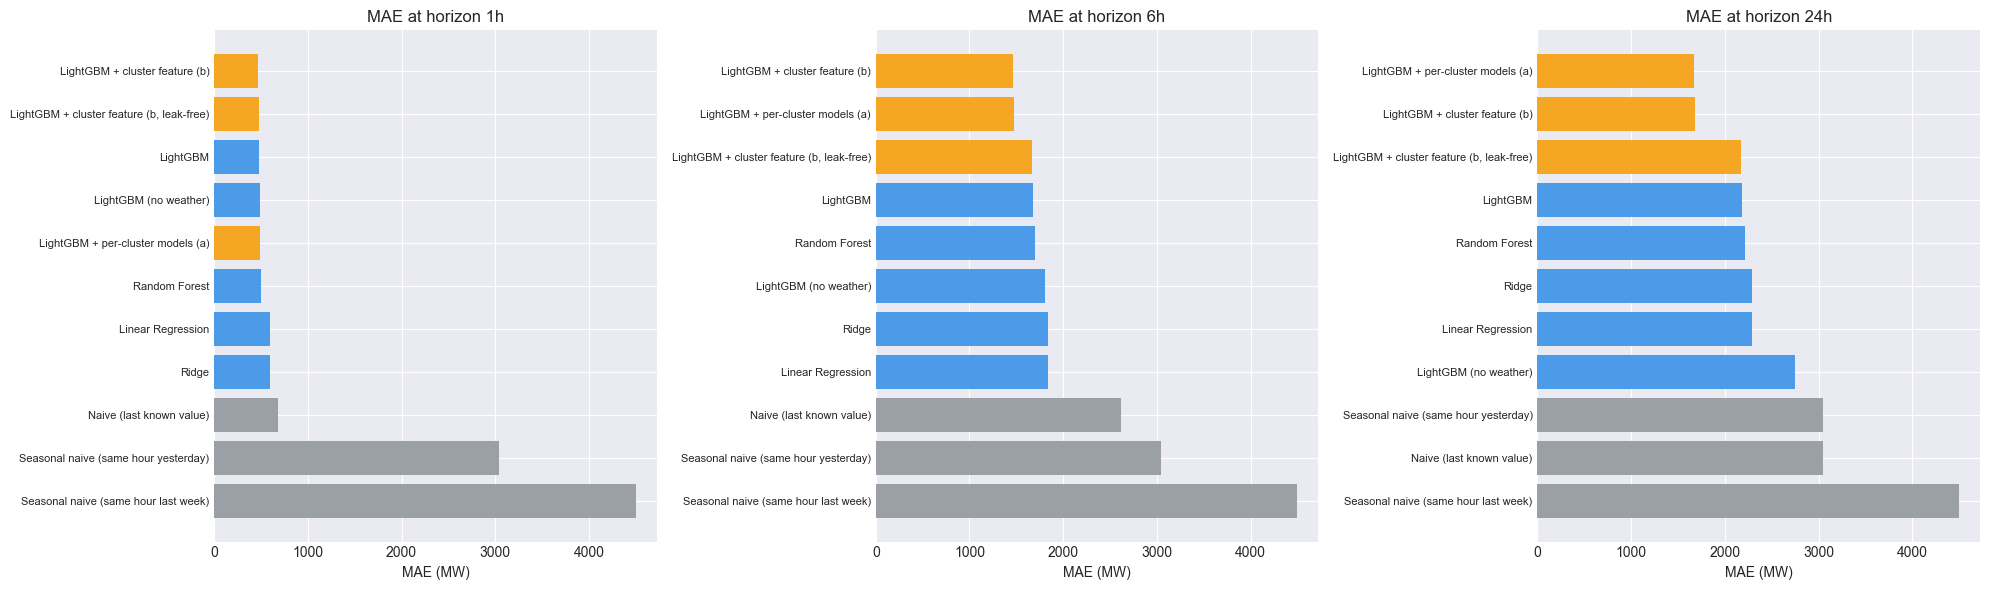

In [36]:
colors = {"Baseline": "#9aa0a6", "Global": "#4C9BE8", "Cluster-aware": "#F5A623"}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, h in zip(axes, HORIZONS):
    d = final[final.Horizon_h == h].sort_values("MAE", ascending=False)
    ax.barh(d.Model, d.MAE, color=[colors[g] for g in d.Group])
    ax.set_title(f"MAE at horizon {h}h"); ax.set_xlabel("MAE (MW)"); ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

**Reading the result:** every machine-learning model beats every baseline at every horizon, and the error grows quickly with the horizon (it is much harder to forecast 24 hours ahead than 1 hour ahead). LightGBM is the best deployable model. The cluster-aware bars (orange) that look best use the same-day label, which leaks the future (next section).

## 13. The cluster-label leakage
We compare global LightGBM with the two ways of adding the cluster label. A **negative** value means the error went down.
- With the **same-day label** the error drops a lot, and the drop grows with the horizon, because at long horizons the model has less recent production and leans on the leaked label.
- With the **D-2 label** (really known at forecast time) the change is almost zero. So the "gain" came from leakage, not from the clusters themselves.

,same-day label (leaky),D-2 label (leak-free)
Horizon_h,,
1,-2.29,-0.22
6,-12.39,-0.19
24,-23.19,-0.37


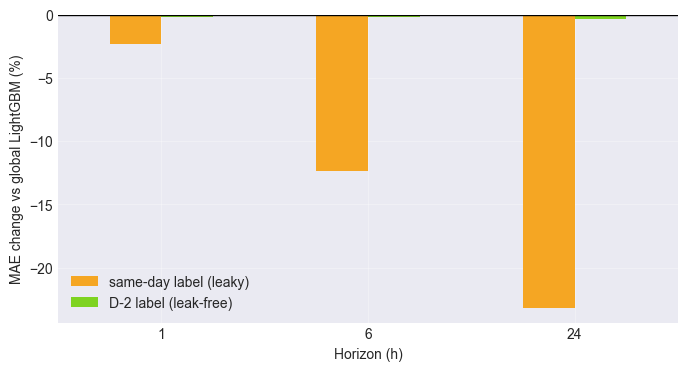

In [37]:
piv = final.pivot_table(index="Horizon_h", columns="Model", values="MAE")
base = piv["LightGBM"]
leak = pd.DataFrame({
    "same-day label (leaky)": 100 * (piv["LightGBM + cluster feature (b)"] - base) / base,
    "D-2 label (leak-free)":  100 * (piv["LightGBM + cluster feature (b, leak-free)"] - base) / base,
})
display(leak.round(2))
leak.plot(kind="bar", figsize=(8, 4), color=["#F5A623", "#7ED321"])
plt.axhline(0, color="k", linewidth=1); plt.ylabel("MAE change vs global LightGBM (%)")
plt.xlabel("Horizon (h)"); plt.xticks(rotation=0); plt.grid(alpha=.3); plt.show()

## 14. Error by season and by cluster
A single average hides where a model fails. Here we look at the MAE of LightGBM per **season** and per **cluster** (Person B's day types), for each horizon.

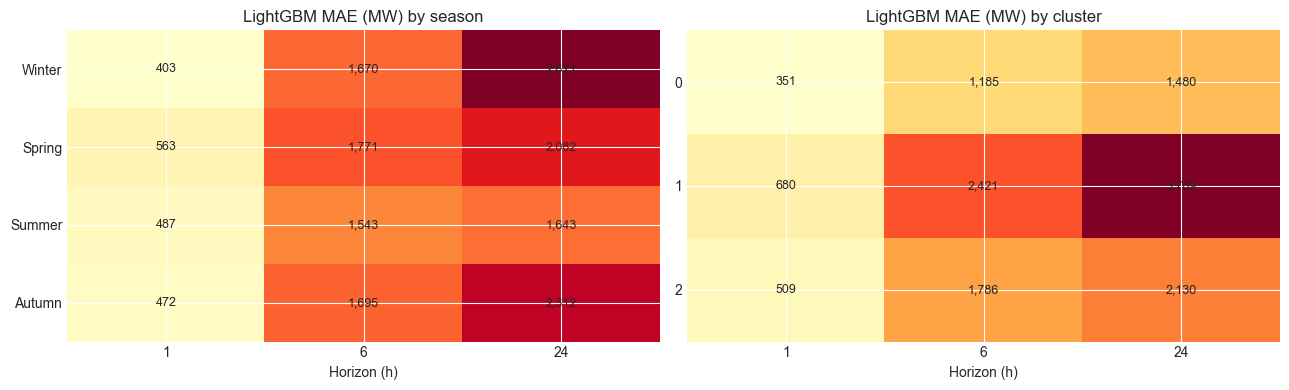

In [38]:
by_season = pd.read_csv(os.path.join(TABLES_DIR, "final_by_season.csv"))
by_cluster = pd.read_csv(os.path.join(TABLES_DIR, "final_by_cluster.csv"))

def heat(ax, table, title):
    im = ax.imshow(table.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(table.shape[1])); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.values[i, j]:,.0f}", ha="center", va="center", fontsize=9)
    ax.set_title(title); ax.set_xlabel("Horizon (h)")

lg = lambda df: df[df.Model == "LightGBM"]
t_season = lg(by_season).pivot(index="Season", columns="Horizon_h", values="MAE").reindex(SEASON_ORDER)
t_cluster = lg(by_cluster).pivot(index="Cluster", columns="Horizon_h", values="MAE")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
heat(ax[0], t_season, "LightGBM MAE (MW) by season"); heat(ax[1], t_cluster, "LightGBM MAE (MW) by cluster")
plt.tight_layout(); plt.show()

**Reading the result:** at 24h the **winter** is by far the hardest season and the **summer** the easiest (the solar cycle is regular in summer). Cluster 1 (the high-production days) is the hardest cluster. Part of that is simply scale, because errors in MW grow when the production level is higher.

## 15. Residual diagnostics
**Residual** = actual - forecast. A good model leaves residuals that look like random noise: around zero, with no correlation between neighbouring hours. If the residual ACF shows correlation, the model is missing a pattern.

For the **naive forecast** at h = 1 (see `05b_residual_diagnostics_naive.png`) the residual ACF is about 0.45 at lag 1 and about 0.4 around lag 24: the errors carry **momentum and a daily pattern** that the naive forecast ignores. Models that use `hour` and past values can learn it. Below we repeat the check for the best ARIMA and for LightGBM.

In [39]:
def plot_residual_diagnostics(y_true: pd.Series, y_pred: pd.Series, model_name: str = "Best Model",
                              filename: str = "05_residual_diagnostics.png"):
    """Generate diagnostic plots for model forecast errors (residuals)."""
    apply_style()
    residuals = (y_true - y_pred).dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    
    # 1. Residual Time Series
    axes[0].plot(residuals.index[-1000:], residuals.iloc[-1000:], alpha=0.75, color="#4A90E2", linewidth=1)
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
    axes[0].set_title(f"Residual Time Series - {model_name} (Last 1000 Hours)")
    axes[0].set_ylabel("Error (MW)")
    axes[0].grid(alpha=0.3)
    
    # 2. Residual Autocorrelation (ACF)
    plot_acf(residuals, lags=36, zero=False, ax=axes[1], color="#7ED321")
    axes[1].set_title(f"Residual ACF (Autocorrelation) - {model_name}")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    savefig(os.path.join(FIGS_DIR, filename))
    plt.close()
    print(f"Saved Residual Diagnostics plot -> results/figures/{filename}")

Saved -> c:\Users\Administrator\Desktop\Wind-Solar-Forecasting\src\..\results\figures\05_residual_diagnostics.png
Saved Residual Diagnostics plot -> results/figures/05_residual_diagnostics.png
Saved -> c:\Users\Administrator\Desktop\Wind-Solar-Forecasting\src\..\results\figures\05b_residual_diagnostics_naive.png
Saved Residual Diagnostics plot -> results/figures/05b_residual_diagnostics_naive.png
Saved -> c:\Users\Administrator\Desktop\Wind-Solar-Forecasting\src\..\results\figures\06_residual_diagnostics_lightgbm.png
Saved Residual Diagnostics plot -> results/figures/06_residual_diagnostics_lightgbm.png
05_residual_diagnostics.png


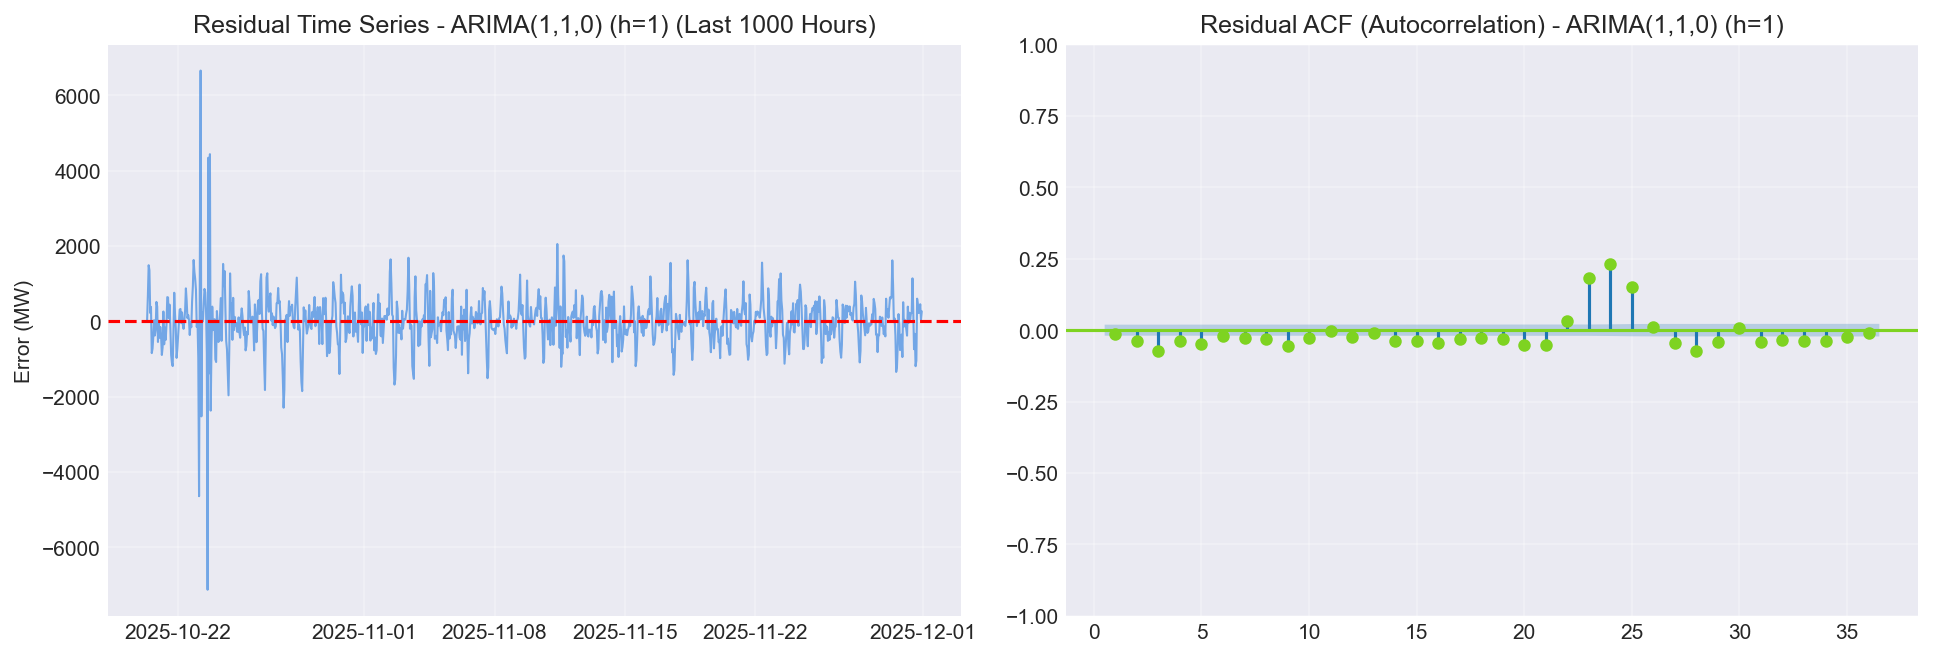

05b_residual_diagnostics_naive.png


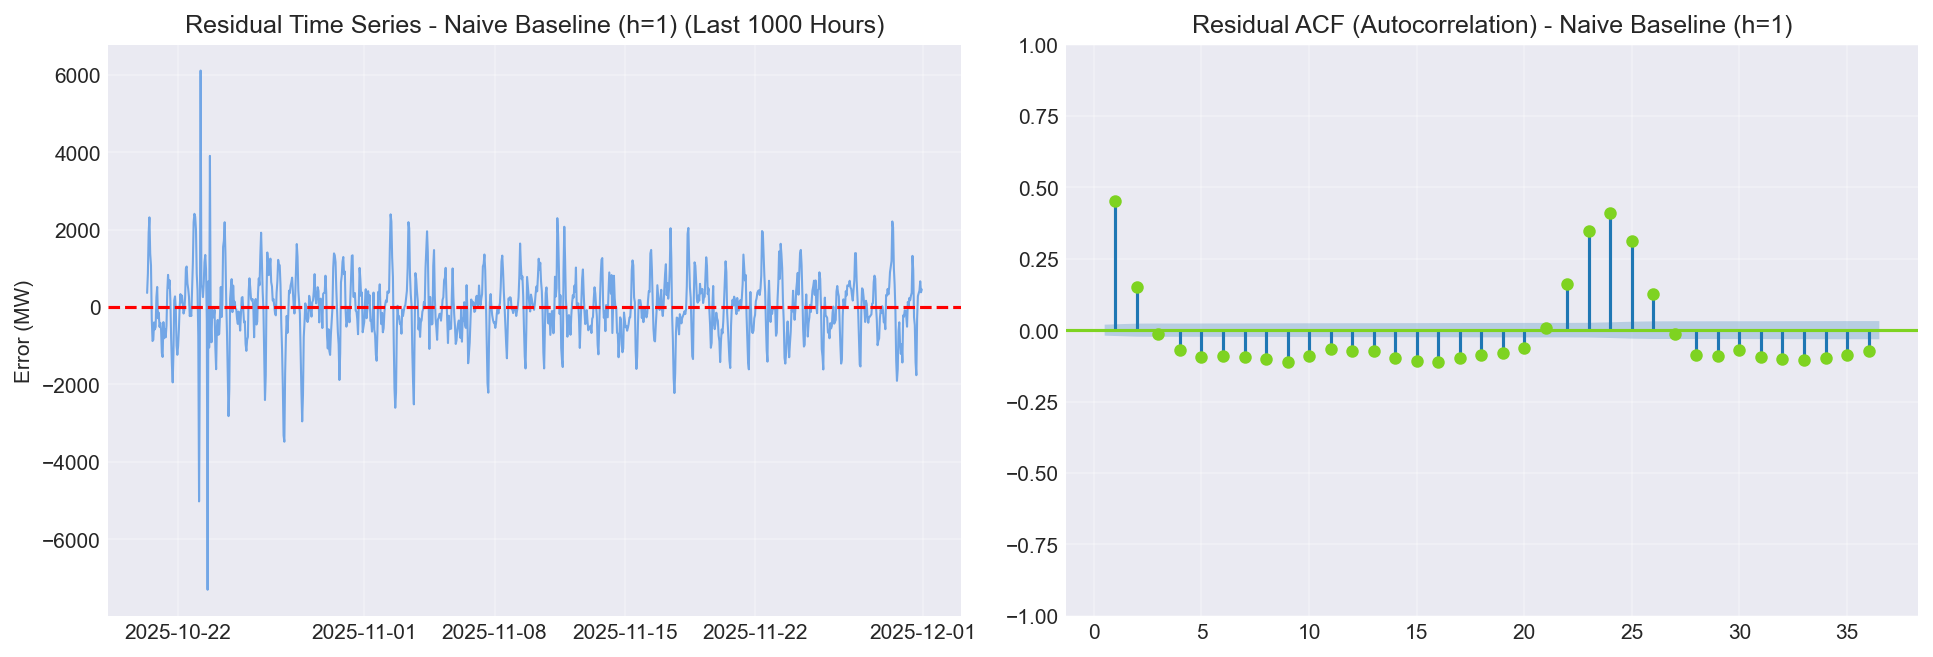

06_residual_diagnostics_lightgbm.png


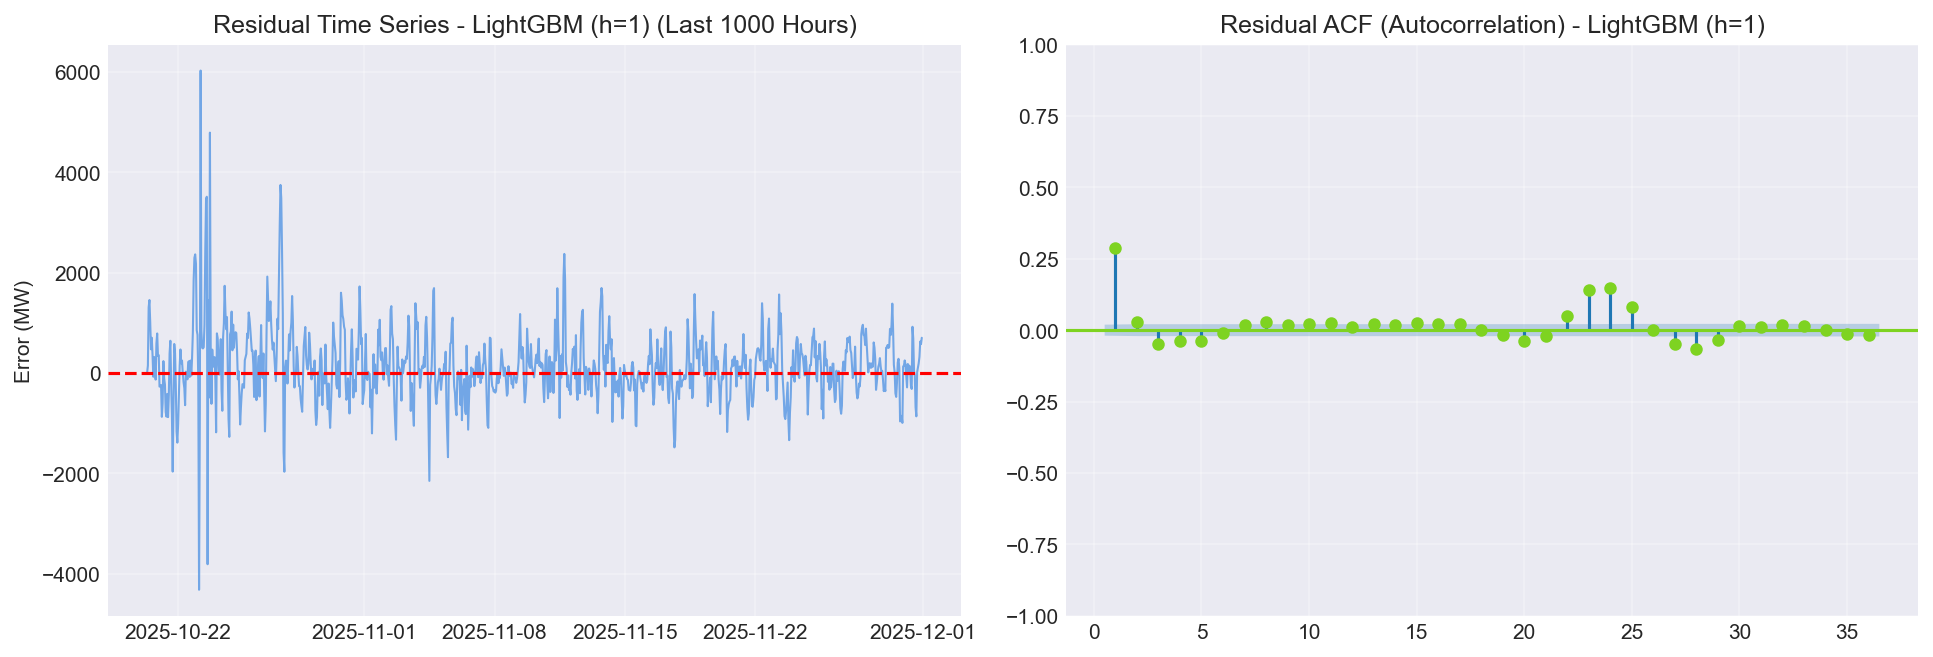

In [40]:
y_test = full.reindex(test.index)

if RUN_ARIMA:   # (extra) residuals of the best ARIMA at h=1 and of the naive forecast
    best_name = df_arima[(df_arima.Horizon_h == 1) & (df_arima.Model.isin(fits.keys()))].sort_values("MAE").iloc[0]["Model"]
    seg = full.loc[test.index.min() - pd.Timedelta(hours=336): test.index.max()]
    one_step = fits[best_name].apply(seg, refit=False).fittedvalues.reindex(test.index)
    plot_residual_diagnostics(y_test, one_step, model_name=f"{best_name} (h=1)", filename="05_residual_diagnostics.png")
    plot_residual_diagnostics(y_test, full.shift(1).reindex(test.index), model_name="Naive Baseline (h=1)",
                              filename="05b_residual_diagnostics_naive.png")

pr1 = pd.read_csv(os.path.join(PRED_DIR, "predictions_h1.csv"), index_col=0, parse_dates=True)
plot_residual_diagnostics(pr1["y_true"], pr1["LightGBM"], model_name="LightGBM (h=1)",
                          filename="06_residual_diagnostics_lightgbm.png")
for f in ["05_residual_diagnostics.png", "05b_residual_diagnostics_naive.png", "06_residual_diagnostics_lightgbm.png"]:
    if os.path.exists(os.path.join(FIGS_DIR, f)):
        print(f); display(Image(os.path.join(FIGS_DIR, f)))

## 16. Forecast vs actual (extra)
One week of the test period at horizon 24h: the actual production, the global LightGBM forecast, and the naive forecast (the last known value, which is yesterday's value at this horizon).

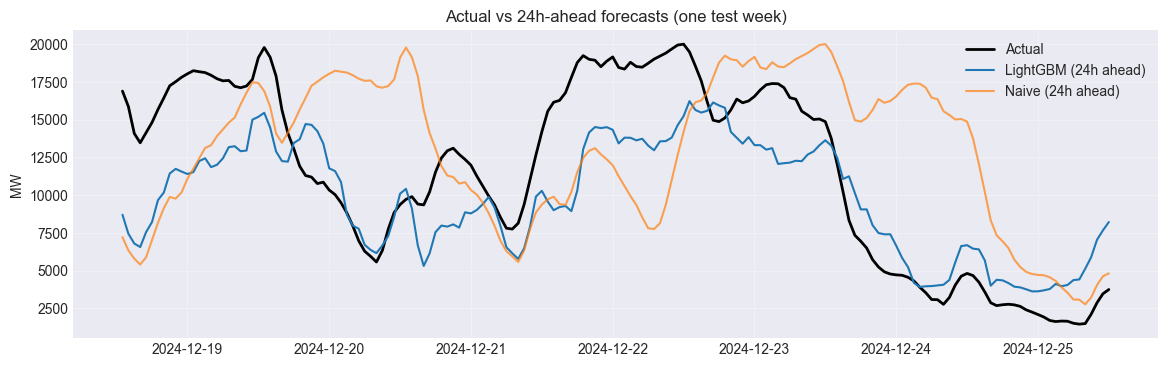

In [41]:
pr24 = pd.read_csv(os.path.join(PRED_DIR, "predictions_h24.csv"), index_col=0, parse_dates=True)
wk = pr24.iloc[2000:2000 + 7 * 24]
plt.figure(figsize=(14, 4))
plt.plot(wk["y_true"], "k", linewidth=2, label="Actual")
plt.plot(wk["LightGBM"], label="LightGBM (24h ahead)")
plt.plot(wk["Naive (last known value)"], alpha=.7, label="Naive (24h ahead)")
plt.ylabel("MW"); plt.title("Actual vs 24h-ahead forecasts (one test week)"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 17. Conclusions and limitations
**Conclusions**
1. Tuned machine-learning models beat all baselines at every horizon. LightGBM improves on the best baseline by about 29% (1h), 36% (6h) and 28% (24h).
2. Weather becomes more important the further ahead we forecast.
3. Cluster-aware modelling gives **no practical gain** once the cluster label is restricted to information known at forecast time. The big gains seen with the same-day label are a **leakage** effect.
4. Classical ARIMA models only capture short-term momentum; they cannot use weather and miss the 24-hour cycle that the supervised models learn.

**Limitations**
- Perfect-weather assumption (we use observed weather, not forecasts), so 6h and 24h results are optimistic.
- The clustering was fitted on all days (including test days).
- Per-cluster models (a) have no leak-free version.
- One chronological split and no significance tests; one winter / spring / summer in the test set.
- A single aggregated target (wind + solar together).

### Appendix: the one-call runner of the diagnostics
`run_full_diagnostics` runs sections 5, 6, 11 and 15 in a single call (it is what `python src/arima_and_diagnostics.py` executes). It is defined here for completeness; we do not call it because the sections above already do the same step by step.

In [42]:
def run_full_diagnostics():
    os.makedirs(TABLES_DIR, exist_ok=True)
    os.makedirs(FIGS_DIR, exist_ok=True)
    
    train, test = load_splits()
    full = regular_hourly_series(train, test)
    scale = mase_scale(full.loc[:train.index.max()], m=24)
    
    # 1. Stationarity
    run_stationarity_tests(full.loc[:train.index.max()])
    
    # 2. ACF / PACF Plots
    plot_acf_pacf_analysis(full.loc[:train.index.max()])
    
    # 3. ARIMA Models (real ARIMA forecasts, evaluated against naive on the same origins)
    df_arima, fits = run_arima_models(full, train.index.max(), test.index, scale)
    
    # 4. Residual Diagnostics
    y_test = full.reindex(test.index)

    # 4a. best ARIMA model at h=1 (one-step-ahead forecasts with the fitted parameters)
    arima_rows = df_arima[(df_arima.Horizon_h == 1) & (df_arima.Model.isin(fits.keys()))]
    if len(arima_rows):
        best_name = arima_rows.sort_values("MAE").iloc[0]["Model"]
        seg = full.loc[test.index.min() - pd.Timedelta(hours=336): test.index.max()]
        one_step = fits[best_name].apply(seg, refit=False).fittedvalues.reindex(test.index)
        plot_residual_diagnostics(y_test, one_step, model_name=f"{best_name} (h=1)",
                                  filename="05_residual_diagnostics.png")

    # 4b. naive baseline (for comparison)
    naive_pred = full.shift(1).reindex(test.index)
    plot_residual_diagnostics(y_test, naive_pred, model_name="Naive Baseline (h=1)",
                              filename="05b_residual_diagnostics_naive.png")

    # 4c. best supervised model (LightGBM) if models.py was already run
    p1 = os.path.join(PRED_DIR, "predictions_h1.csv")
    if os.path.exists(p1):
        pr = pd.read_csv(p1, index_col=0, parse_dates=True)
        if "LightGBM" in pr.columns:
            plot_residual_diagnostics(pr["y_true"], pr["LightGBM"], model_name="LightGBM (h=1)",
                                      filename="06_residual_diagnostics_lightgbm.png")
    
    print("\n=== All Time-Series Lecture Diagnostics Completed Successfully! ===")